Initial Data:
   Water_consumption  Days
0                200     1
1                190     2
2                211     3
3                212     4
4                213     5

Average water consumption: 205.20 liters

Daily Change:
   Water_consumption  Days  Difference
0                200     1         NaN
1                190     2       -10.0
2                211     3        21.0
3                212     4         1.0
4                213     5         1.0

Average daily increase in water consumption: 3.25 liters

Water shortage starts on Day 3
Shortage amount on that day: 6 liters


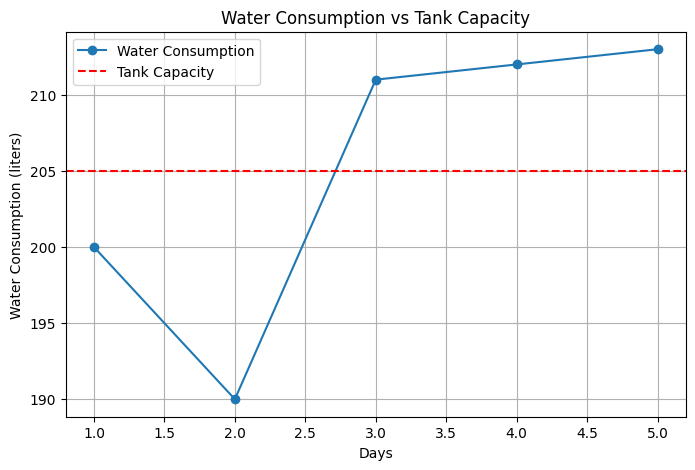

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.DataFrame(
    {
        "Water_consumption": [200, 190, 211, 212, 213],
        "Days": [1, 2, 3, 4, 5]
    }
)

print("Initial Data:")
print(data)

avg = data['Water_consumption'].mean()
print(f"\nAverage water consumption: {avg:.2f} liters")

data['Difference'] = data['Water_consumption'].diff()

print("\nDaily Change:")
print(data)

avg_increase = data['Difference'].mean()
print(f"\nAverage daily increase in water consumption: {avg_increase:.2f} liters")

tank_capacity = 205

data['Shortage'] = data['Water_consumption'] > tank_capacity

shortage_days = data[data['Shortage']]

if not shortage_days.empty:
    first_shortage_day = shortage_days.iloc[0]['Days']
    shortage_amount = shortage_days.iloc[0]['Water_consumption'] - tank_capacity

    print(f"\nWater shortage starts on Day {int(first_shortage_day)}")
    print(f"Shortage amount on that day: {shortage_amount} liters")
else:
    print("\nNo water shortage detected.")

plt.figure(figsize=(8,5))
plt.plot(data['Days'], data['Water_consumption'],
         marker='o', label='Water Consumption')
plt.axhline(y=tank_capacity, color='r',
            linestyle='--', label='Tank Capacity')
plt.xlabel("Days")
plt.ylabel("Water Consumption (liters)")
plt.title("Water Consumption vs Tank Capacity")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
last_day_consumption = data['Water_consumption'].iloc[-1]
predicted_consumption_day6 = last_day_consumption + avg_increase

new_data = pd.DataFrame({
    'Water_consumption': [predicted_consumption_day6],
    'Days': [6],
    'Difference': [avg_increase],
    'Shortage': [predicted_consumption_day6 > tank_capacity]
})
data = pd.concat([data, new_data], ignore_index=True)

print("\nUpdated Data with Day 6 Prediction:")
print(data)


Updated Data with Day 6 Prediction:
   Water_consumption  Days  Difference  Shortage
0             200.00     1         NaN     False
1             190.00     2      -10.00     False
2             211.00     3       21.00      True
3             212.00     4        1.00      True
4             213.00     5        1.00      True
5             216.25     6        3.25      True


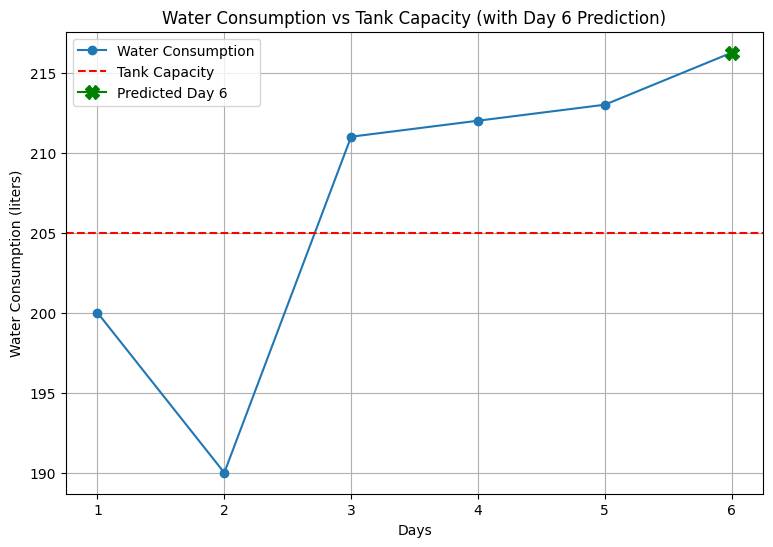

In [5]:
plt.figure(figsize=(9, 6))
plt.plot(data['Days'], data['Water_consumption'],
         marker='o', linestyle='-', label='Water Consumption')
plt.axhline(y=tank_capacity, color='r',
            linestyle='--', label='Tank Capacity')

# Highlight the predicted point
plt.plot(data['Days'].iloc[-1], data['Water_consumption'].iloc[-1],
         marker='X', markersize=10, color='green', label='Predicted Day 6')

plt.xlabel("Days")
plt.ylabel("Water Consumption (liters)")
plt.title("Water Consumption vs Tank Capacity (with Day 6 Prediction)")
plt.legend()
plt.grid(True)
plt.xticks(data['Days'])

plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB
       Temperature     Humidity   Wind_Speed  Cloud_Cover     Pressure
count  2500.000000  2500.000000  2500.000000  2500.000000  2500.000000
mean     22.581725    64.347094     9.906255    49.658104  1014.312336
std       7.326996    19.954739     5.780316    29.123104    20.196433
min      10.001842    30.005071     0.009819     0.015038   980.014486
25%      16.359398    47.339815     4.761909    23.900016   996.938630
50%      22.536448    63.920797     9.908572    49.488284  1013.433035
75%    

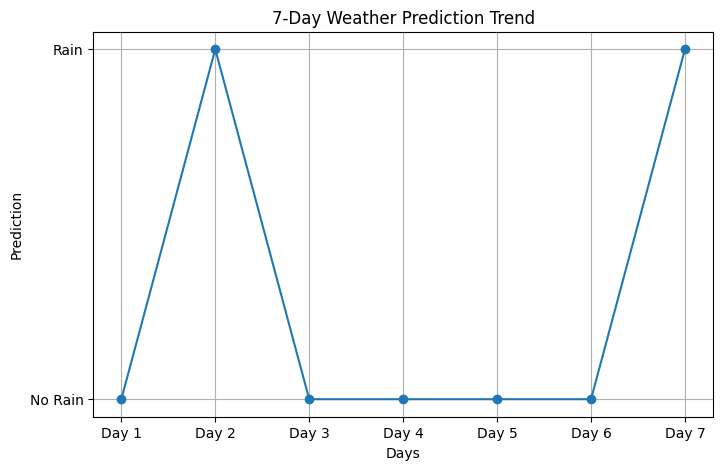

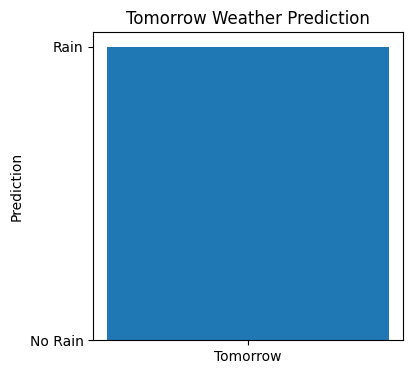

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/weather_forecast_data.csv')
df.info()
print(df.describe())
avg_humidity = df['Humidity'].mean()
avg_cloud = df['Cloud_Cover'].mean()

days = []
predictions = []

for i, row in enumerate(df.tail(7).itertuples(), start=1):

    humidity = row.Humidity
    cloud_cover = row.Cloud_Cover

    if humidity > avg_humidity and cloud_cover > avg_cloud:
        pred = "Rain"
        value = 1
    else:
        pred = "No Rain"
        value = 0

    days.append(f"Day {i}")
    predictions.append(value)
    tomorrow_humidity = df['Humidity'].iloc[-1]
tomorrow_cloud = df['Cloud_Cover'].iloc[-1]

print("\nTomorrow's Data")
print("Humidity:", tomorrow_humidity)
print("Cloud Cover:", tomorrow_cloud)

if tomorrow_humidity > avg_humidity and tomorrow_cloud > avg_cloud:
    print("\nTomorrow Prediction: Rain")
else:
    print("\nTomorrow Prediction: No Rain")

plt.figure(figsize=(8,5))
plt.plot(days, predictions, marker='o')

plt.title("7-Day Weather Prediction Trend")
plt.xlabel("Days")
plt.ylabel("Prediction")
plt.yticks([0,1], ["No Rain", "Rain"])

plt.grid(True)
plt.show()
prediction = 1 if (tomorrow_humidity > avg_humidity and tomorrow_cloud > avg_cloud) else 0

plt.figure(figsize=(4,4))
plt.bar(["Tomorrow"], [prediction])

plt.title("Tomorrow Weather Prediction")
plt.ylabel("Prediction")
plt.yticks([0,1], ["No Rain", "Rain"])

plt.show()